In [1]:
from pathlib import Path

import numpy as np
import tifffile

import matplotlib.pyplot as plt
import pymeshlab

from blender_tissue_cartography import interface_pymeshlab as intmsl
from blender_tissue_cartography import interpolation as tcinterp
from blender_tissue_cartography import mesh as tcmesh
from blender_tissue_cartography import remesh_pymeshlab as tcremesh_pymeshlab

from scipy.stats import mode
from sklearn.cluster import DBSCAN

from skimage.feature import peak_local_max
from skimage.filters import difference_of_gaussians

# Load image and detect peaks

You should use the final deconvolved timepoint for this, when there are the most nuclei (provides a better mesh)
and the nuclei are as bright as possible

In [24]:
# edit this cell to point to your data

base_path = Path(r"D:\Tracking\NucleiTracking\data\interim\lightsheet\2025_11_06_bcd\recon")
img_name = "recon_fused_tp_324_ch_0.tif"

This usually works first try, but you can adjust the parameters if needed.

We use a difference of gaussians filter to enhance the nuclei, then detect local maxima as candidate nuclei centers.

In [4]:
arr = tifffile.imread(base_path / img_name)

dog = difference_of_gaussians(arr, 2, 6)
peaks = peak_local_max(dog, min_distance=5, threshold_abs=35)

Uncomment this cell if you want to visualize the detected peaks in napari

In [ ]:
# import napari
#
# viewer = napari.Viewer()
#
# points = viewer.add_points(peaks[:], size=5)
# img = viewer.add_image(arr, name="Image")
#
# napari.run()

We use dbscan to find the largest cluster of points, which should correspond to the main body of the sample.

This also usually works very well first try.

In [6]:
dbscan = DBSCAN(eps=15, min_samples=1)
vals = dbscan.fit_predict(peaks)
vmax = mode(vals)
vmax = vmax.mode
print(vmax)

0


Visualize the clustered points in napari, coloring the largest cluster in red

In [ ]:
# viewer = napari.Viewer()

# colors = ["black" if val == vmax else "red" for val in vals]
# viewer.add_points(peaks[:], face_color=colors, size=5)
# napari.run()

# Convert to mesh and export to blender object

Use pymeshlab and the blender tissue cartography package to reconstruct a surface mesh from the point cloud of detected nuclei centers.

This is documented in detail in the blender tissue cartography documentation:
https://nikolas-claussen.github.io/blender-tissue-cartography/

In [8]:
point_cloud = tcmesh.ObjMesh(vertices=peaks[vals == vmax], faces=[])
point_cloud_pymeshlab = intmsl.convert_to_pymeshlab(point_cloud)

ms = pymeshlab.MeshSet()
ms.add_mesh(point_cloud_pymeshlab)

ms.compute_normal_for_point_clouds(k=20, smoothiter=2)
ms.generate_surface_reconstruction_screened_poisson(
    depth=8,
    fulldepth=5,
)

ms.meshing_isotropic_explicit_remeshing(
    iterations=10, targetlen=pymeshlab.PercentageValue(1)
)

mesh_reconstructed = intmsl.convert_from_pymeshlab(ms.current_mesh())

mesh_reconstructed.write_obj(base_path / "dog_peaks.obj")

## Next steps

You should follow the instructions in the blender tissue cartography documentation to generate UV maps
for the mesh,then export the mesh with UVs as an obj file again. This is how I do it:

1. Import the mesh into blender
- open a new blender project, and delete the default cube
- drag in the dog_peaks.obj file you just created
- for import options,
    - decrease the scale to 0.01 (to make the mesh a useable size)
    - set forward to Y and up to Z

2. Mark seams for UV mapping

_My general strategy is to do this step a couple of times to create overlapping regions with minimal
stretching, and export the blender objects each time with different names_

- The documentation shows how to mark existing edges, but I prefer to create my own seams
- Go into uv editing tap, switch to edit mode, turn on edge view, and use the bisect tool to create edges for the UV map
- For each edge, select it and press ctrl+E -> mark seam
    - You can alt left click to select an entire edge loop, which should make your life easier
- Select the entire mesh (A), then press U to unwrap
    - I usually use "Minimal Stretch" as the unwrap method
- The entire mesh has to be unwrapped, so if you only want segmentation to happen on a part of the mesh, make the other parts very small in the UV map
    - You can use L to select linked faces in the UV editor, then scale them down to a tiny size with S

3. Export the mesh with UVs
- Go into the layout tab, or switch back to object mode
- Select the mesh, then go to File -> Export -> Wavefront (.obj)
- In the export options
    - Make sure "Include UVs" is checked
    - Set scale to 100
    - Forward to Y and Up to Z
- Save the obj file in the same folder as before, with a different name (e.g. top.obj)

4. Next steps
- Run the remainder of the notebook to check to make sure the UV mapping and projection is working correctly
- Transfer the .obj files with uvs to FI server for next step (batched/uv_unrwap.sh)


# test UV mapping and projection of image data onto the mesh

In [28]:
path_to_uv_obj = base_path.parent / "poles.obj"

In [29]:
mesh_uv = tcmesh.ObjMesh.read_obj(str(path_to_uv_obj))
normal_offsets = np.linspace(-12, 8, 21)
mapping_arr = tifffile.imread(base_path / img_name)

In [30]:
# if this runs without errors, you should be good to go
# if it gives you a warning about fallback, you might need to try generating the uv map again with different seams

mesh = mesh_uv

image = np.expand_dims(mapping_arr, axis=0)
uv_grid_steps = 1024
map_back = True
use_fallback = "auto"
resolution = (1, 1, 1)

interpolated_3d_positions = tcinterp.interpolate_per_vertex_field_to_UV(
    mesh,
    mesh.vertices,
    domain="per-vertex",
    uv_grid_steps=uv_grid_steps,
    distance_threshold=0.0000001,
    map_back=map_back,
    use_fallback=use_fallback,
)
interpolated_normals = tcinterp.interpolate_per_vertex_field_to_UV(
    mesh,
    mesh.normals,
    domain="per-vertex",
    uv_grid_steps=uv_grid_steps,
    distance_threshold=0.0000001,
    map_back=map_back,
    use_fallback=use_fallback,
)
projected_data = tcinterp.interpolate_volumetric_data_to_uv_multilayer(
    image, interpolated_3d_positions, interpolated_normals, normal_offsets, resolution
)
print("Image shape:", projected_data.shape)

Image shape: (1, 21, 1024, 1024)


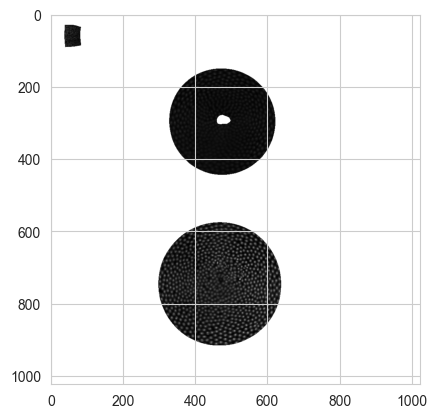

In [31]:
plt.imshow(np.max(projected_data[0], axis=0), cmap="gray")
plt.show()